Xavier Activation Mean
[0.40313923358917236, 0.28463372588157654, 0.17227748036384583, 0.12121069431304932, 0.07590041309595108, 0.04426489397883415, 0.031530074775218964, 0.02135859616100788, 0.019203606992959976, 0.012727013789117336, 0.00826272089034319, 0.006481335498392582, 0.003687362652271986, 0.0029207421466708183, 0.0025089557748287916, 0.0015398772666230798, 0.001047218800522387, 0.0010543589014559984, 0.0006972445989958942, 0.0005823957035318017]

Kaiming Activation Mean
[0.582459568977356, 0.7045978903770447, 0.6318331956863403, 0.7184503674507141, 0.7259713411331177, 0.6177059412002563, 0.6701065897941589, 0.3778253197669983, 0.4309588372707367, 0.5398496985435486, 0.6391124129295349, 0.7770524621009827, 0.440464586019516, 0.4717999994754791, 0.5214351415634155, 0.4517218768596649, 0.3903890550136566, 0.5491907596588135, 0.43601131439208984, 0.31149396300315857]


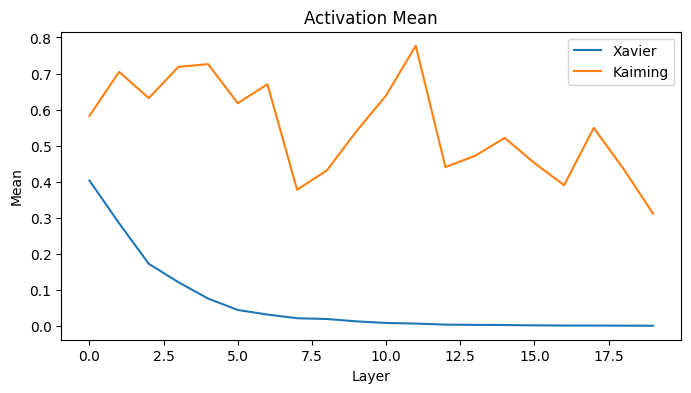

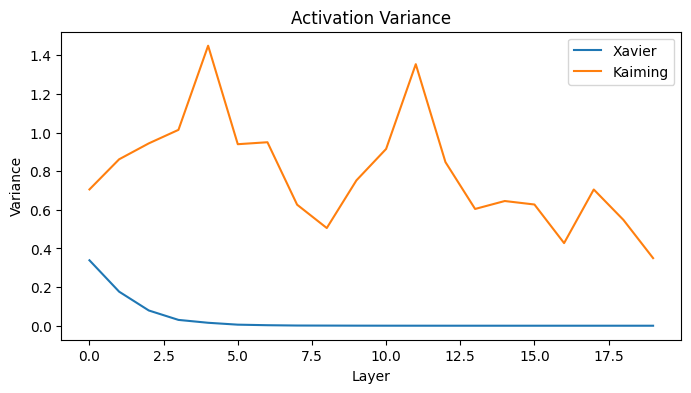

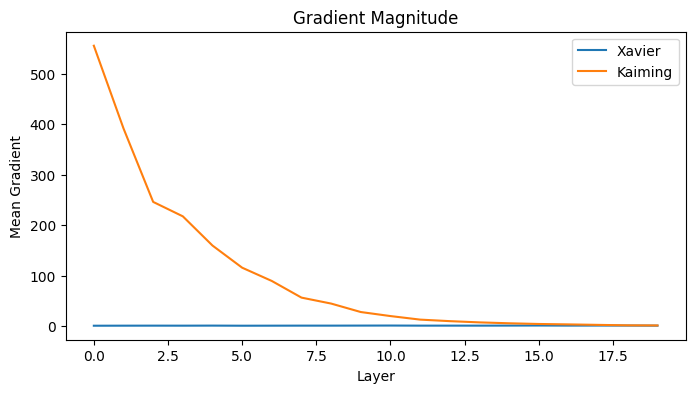

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Input Data
torch.manual_seed(42)

X = torch.randn(100, 50)

layers = 20
size = 50

# Xavier Initialization
def xavier(in_features, out_features):
    limit = np.sqrt(6 / (in_features + out_features))
    W = torch.rand(in_features, out_features) * 2 * limit - limit
    W.requires_grad = False
    return W

# Kaiming Initialization
def kaiming(in_features, out_features):
    W = torch.randn(in_features, out_features) * np.sqrt(2 / in_features)
    W.requires_grad = False
    return W

# Function to Analyze Network
def analyze_network(init_function):

    weights = [init_function(size, size) for _ in range(layers)]

    activation_mean = []
    activation_variance = []
    gradient_mean = []

    A = X

    # Forward Pass
    for W in weights:

        Z = A @ W
        A = torch.relu(Z)

        activation_mean.append(A.mean().item())
        activation_variance.append(A.var().item())

    # Dummy Gradient (Manual)
    grad = torch.ones_like(A)

    # Backward Pass (Manual Gradient Tracking)
    for W in reversed(weights):

        grad = grad @ W.T

        gradient_mean.append(grad.abs().mean().item())

    gradient_mean.reverse()

    return activation_mean, activation_variance, gradient_mean

# Xavier Results
x_mean, x_var, x_grad = analyze_network(xavier)

# Kaiming Results
k_mean, k_var, k_grad = analyze_network(kaiming)

# Print Results
print("Xavier Activation Mean")
print(x_mean)

print("\nKaiming Activation Mean")
print(k_mean)

# Plot Activation Mean
plt.figure(figsize=(8,4))
plt.plot(x_mean, label="Xavier")
plt.plot(k_mean, label="Kaiming")
plt.title("Activation Mean")
plt.xlabel("Layer")
plt.ylabel("Mean")
plt.legend()
plt.show()

# Plot Activation Variance
plt.figure(figsize=(8,4))
plt.plot(x_var, label="Xavier")
plt.plot(k_var, label="Kaiming")
plt.title("Activation Variance")
plt.xlabel("Layer")
plt.ylabel("Variance")
plt.legend()
plt.show()

# Plot Gradient Magnitude
plt.figure(figsize=(8,4))
plt.plot(x_grad, label="Xavier")
plt.plot(k_grad, label="Kaiming")
plt.title("Gradient Magnitude")
plt.xlabel("Layer")
plt.ylabel("Mean Gradient")
plt.legend()
plt.show()